### Exercise 3.1: Solving Cartpole and Lunar Lander with A2C (easy)

Implement the Advantage Actor-Critic (A2C) algorithm and use it to solve both `Cartpole` (to validate your implementation) and the [Lunar Lander Environment](https://gymnasium.farama.org/environments/box2d/lunar_lander/). This environment is a little bit harder than Cartpole, but not much. Make sure you perform the appropriate types of analyses to quantify and qualify the performance of your agents.

**Why choose this exercise?** A2C is a good, "pure" TD-based reinforcement learning algorithm and is the basis for more advanced Policy Gradient approaches. Having a good understanding of it is a good starting point for diving into the state-of-the-art in on-policy Deep Reinforcement Learning.


In [1]:
import sys
sys.path.append("/mnt/c/Users/checc/OneDrive/Desktop/Reinforcment LLM/DLA_3")

import importlib
import a2c as a2c_module
importlib.reload(a2c_module)

import gymnasium as gym
import numpy as np
import torch
import matplotlib.pyplot as plt

from torch.distributions import Categorical

from a2c import (
    A2CNet,
    A2CNetLunarStable,
    A2CNetLunarSeparate,
    a2c,
    a2c_rollout,
    a2c_vectorized,
    a2c_vectorized_lunarlander_stable,
    cartpole_obs_scale,
    lunarlander_obs_scale,
    lunarlander_obs_scale_raw,
    run_episode_greedy,
)

print("Reloaded!")

Reloaded!


In [2]:
import gymnasium as gym
print(gym.__version__)

1.3.0


CARTPOLE

In [4]:
# === CARTPOLE — validazione A2C con GAE ===
seed = 2112

torch.manual_seed(seed)
np.random.seed(seed)

env = gym.make("CartPole-v1")
env.reset(seed=seed)

net_cp = A2CNet(env)
obs_scale = cartpole_obs_scale()

results_cp = a2c(
    net_cp,
    env,
    obs_scale,

    gamma=0.98,

    lr=7e-4,
    lr_critic=1e-3,

    entropy_coef=0.001,
    entropy_coef_min=0.0,

    value_coef=0.5,

    num_episodes=800,

    eval_every=25,
    eval_episodes=20,

    solved_threshold=475.0,

    return_mode="gae",
    gae_lambda=0.95,

    optimizer="adam",

    env_name="cartpole_gae_gamma098",
    checkpoint_path="best_a2c_cartpole_gae_gamma098.pt",

    normalize_advantage=True,
    grad_clip=0.5,

    stop_when_solved=True,
)

📈 New best TRAINING average: AvgReturn = 20.00

Episode: 0
  Return:            20.00
  Avg Return (±std): 20.00 ± 0.00
  Episode Length:    20
  Actor Loss:        0.0026
  Critic Loss:       6.5184
  Entropy:           0.6929
  Entropy coef:      0.00100
  Running Reward:    1.00
💾 New best EVAL model saved to best_a2c_cartpole_gae_gamma098.pt! EvalReturn = 11.15
  [EVAL ep.0] AvgReturn: 11.2 | AvgLength: 11.2
  [EVAL ep.25] AvgReturn: 9.3 | AvgLength: 9.3
📈 New best TRAINING average: AvgReturn = 21.20

Episode: 50
  Return:            31.00
  Avg Return (±std): 21.20 ± 9.16
  Episode Length:    31
  Actor Loss:        0.0217
  Critic Loss:       6.9247
  Entropy:           0.6745
  Entropy coef:      0.00094
  Running Reward:    20.41
  [EVAL ep.50] AvgReturn: 9.2 | AvgLength: 9.2
  [EVAL ep.75] AvgReturn: 9.2 | AvgLength: 9.2

Episode: 100
  Return:            24.00
  Avg Return (±std): 18.84 ± 8.84
  Episode Length:    24
  Actor Loss:        0.0797
  Critic Loss:       3.8337
  E

In [6]:
# === Final greedy evaluation on CartPole ===

net_cp.load_state_dict(torch.load("best_a2c_cartpole_gae_gamma098.pt"))
net_cp.eval()

n_eval = 100
greedy_returns = []
greedy_lengths = []

with torch.no_grad():
    for _ in range(n_eval):
        _, _, rewards = run_episode_greedy(env, net_cp, obs_scale)
        greedy_returns.append(sum(rewards))
        greedy_lengths.append(len(rewards))

print("CARTPOLE FINAL GREEDY EVALUATION")
print(f"Average return: {np.mean(greedy_returns):.1f}")
print(f"Std return:     {np.std(greedy_returns):.1f}")
print(f"Average length: {np.mean(greedy_lengths):.1f}")
print(f"Max return:     {np.max(greedy_returns):.1f}")
print(f"Min return:     {np.min(greedy_returns):.1f}")

CARTPOLE FINAL GREEDY EVALUATION
Average return: 500.0
Std return:     0.0
Average length: 500.0
Max return:     500.0
Min return:     500.0


Grafici

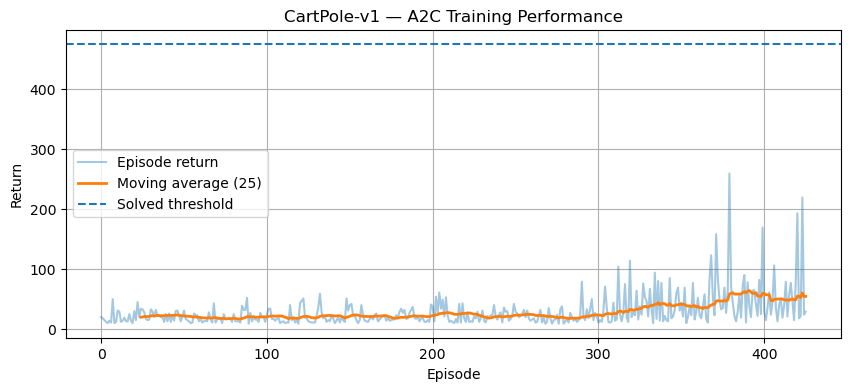

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(results_cp["episode_returns"], alpha=0.4, label="Episode return")

window = 25
moving_avg = np.convolve(
    results_cp["episode_returns"],
    np.ones(window) / window,
    mode="valid"
)

plt.plot(
    range(window - 1, window - 1 + len(moving_avg)),
    moving_avg,
    label=f"Moving average ({window})",
    linewidth=2
)

plt.axhline(475, linestyle="--", label="Solved threshold")
plt.xlabel("Episode")
plt.ylabel("Return")
plt.title("CartPole-v1 — A2C Training Performance")
plt.legend()
plt.grid(True)
plt.show()

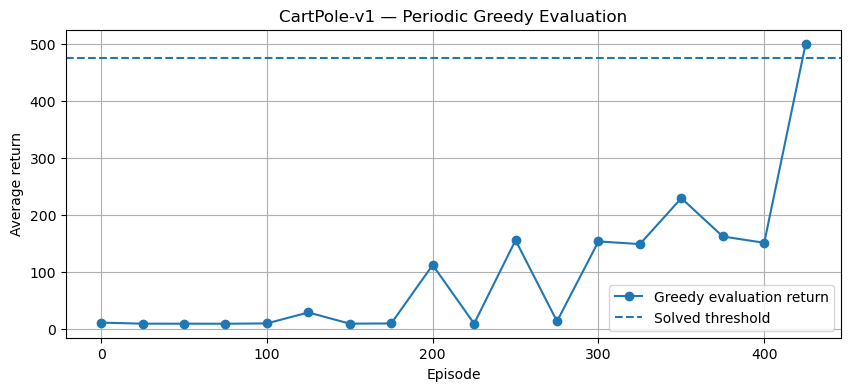

In [9]:
eval_x = np.arange(len(results_cp["eval_avg_returns"])) * 25

plt.figure(figsize=(10, 4))
plt.plot(
    eval_x,
    results_cp["eval_avg_returns"],
    marker="o",
    label="Greedy evaluation return"
)

plt.axhline(475, linestyle="--", label="Solved threshold")
plt.xlabel("Episode")
plt.ylabel("Average return")
plt.title("CartPole-v1 — Periodic Greedy Evaluation")
plt.legend()
plt.grid(True)
plt.show()

In [10]:
# === Visual qualitative check: CartPole greedy policy ===

env_vis = gym.make("CartPole-v1", render_mode="human")

net_cp.load_state_dict(torch.load("best_a2c_cartpole_gae_gamma098.pt"))
net_cp.eval()

with torch.no_grad():
    _, _, rewards = run_episode_greedy(env_vis, net_cp, obs_scale)

env_vis.close()

print(f"Rendered greedy episode return: {sum(rewards)}")
print(f"Episode length: {len(rewards)}")

Rendered greedy episode return: 500.0
Episode length: 500


Fuzioni helper

In [3]:
def evaluate_lunarlander_detailed(env, net, obs_scale, n_eval=50, maxlen=1000):
    net.eval()

    returns = []
    lengths = []
    all_actions = []

    n_terminated = 0
    n_truncated = 0

    with torch.no_grad():
        for _ in range(n_eval):
            obs, _ = env.reset()
            ep_return = 0.0
            ep_length = 0

            terminated = False
            truncated = False

            for _ in range(maxlen):
                obs_t = torch.tensor(obs, dtype=torch.float32) / obs_scale
                probs = net.get_action_probs(obs_t, temperature=1e-8)
                action = probs.argmax().item()

                obs, reward, terminated, truncated, _ = env.step(action)

                ep_return += reward
                ep_length += 1
                all_actions.append(action)

                if terminated or truncated:
                    break

            returns.append(ep_return)
            lengths.append(ep_length)

            if terminated:
                n_terminated += 1
            if truncated:
                n_truncated += 1

    action_counts = np.bincount(all_actions, minlength=env.action_space.n)
    action_freq = action_counts / action_counts.sum()

    returns_np = np.array(returns)

    print("LUNARLANDER DETAILED GREEDY EVALUATION")
    print(f"Average return:       {returns_np.mean():.2f}")
    print(f"Std return:           {returns_np.std():.2f}")
    print(f"Min return:           {returns_np.min():.2f}")
    print(f"Max return:           {returns_np.max():.2f}")
    print(f"Average length:       {np.mean(lengths):.2f}")
    print(f"Success rate >= 200:  {np.mean(returns_np >= 200) * 100:.1f}%")
    print(f"Terminated episodes:  {n_terminated}/{n_eval}")
    print(f"Truncated episodes:   {n_truncated}/{n_eval}")

    print("\nAction frequencies:")
    print(f"  Action 0 - do nothing:   {action_freq[0]:.3f}")
    print(f"  Action 1 - left engine:  {action_freq[1]:.3f}")
    print(f"  Action 2 - main engine:  {action_freq[2]:.3f}")
    print(f"  Action 3 - right engine: {action_freq[3]:.3f}")

    return {
        "returns": returns,
        "lengths": lengths,
        "action_counts": action_counts,
        "action_freq": action_freq,
        "terminated": n_terminated,
        "truncated": n_truncated,
    }

In [4]:
from torch.distributions import Categorical

def evaluate_lunarlander_stochastic(env, net, obs_scale, n_eval=100, maxlen=1000):
    net.eval()

    returns = []
    lengths = []
    all_actions = []

    n_terminated = 0
    n_truncated = 0

    with torch.no_grad():
        for _ in range(n_eval):
            obs, _ = env.reset()
            ep_return = 0.0
            ep_length = 0

            terminated = False
            truncated = False

            for _ in range(maxlen):
                obs_t = torch.tensor(obs, dtype=torch.float32) / obs_scale

                logits, _ = net.get_logits_and_value(obs_t)
                dist = Categorical(logits=logits)
                action = dist.sample().item()

                obs, reward, terminated, truncated, _ = env.step(action)

                ep_return += reward
                ep_length += 1
                all_actions.append(action)

                if terminated or truncated:
                    break

            returns.append(ep_return)
            lengths.append(ep_length)

            if terminated:
                n_terminated += 1
            if truncated:
                n_truncated += 1

    action_counts = np.bincount(all_actions, minlength=env.action_space.n)
    action_freq = action_counts / action_counts.sum()

    returns_np = np.array(returns)

    print("LUNARLANDER STOCHASTIC EVALUATION")
    print(f"Average return:       {returns_np.mean():.2f}")
    print(f"Std return:           {returns_np.std():.2f}")
    print(f"Min return:           {returns_np.min():.2f}")
    print(f"Max return:           {returns_np.max():.2f}")
    print(f"Average length:       {np.mean(lengths):.2f}")
    print(f"Success rate >= 200:  {np.mean(returns_np >= 200) * 100:.1f}%")
    print(f"Terminated episodes:  {n_terminated}/{n_eval}")
    print(f"Truncated episodes:   {n_truncated}/{n_eval}")

    print("\nAction frequencies:")
    print(f"  Action 0 - do nothing:   {action_freq[0]:.3f}")
    print(f"  Action 1 - left engine:  {action_freq[1]:.3f}")
    print(f"  Action 2 - main engine:  {action_freq[2]:.3f}")
    print(f"  Action 3 - right engine: {action_freq[3]:.3f}")

    return {
        "returns": returns,
        "lengths": lengths,
        "action_freq": action_freq,
        "terminated": n_terminated,
        "truncated": n_truncated,
    }

In [5]:
def make_lunarlander_env(seed):
    def _init():
        env = gym.make("LunarLander-v3", enable_wind=False)
        env.reset(seed=seed)
        env.action_space.seed(seed)
        return env
    return _init

LUNAR-Lander

In [ ]:
# === LUNARLANDER — Phase 1: A2C with GAE, stabilized configuration ===

seed = 2112

torch.manual_seed(seed)
np.random.seed(seed)

env_ll = gym.make("LunarLander-v3", enable_wind=False)
env_ll.reset(seed=seed)
env_ll.action_space.seed(seed)

net_ll = A2CNet(env_ll)
obs_scale_ll = lunarlander_obs_scale()

results_ll = a2c(
    net_ll,
    env_ll,
    obs_scale_ll,

    gamma=0.99,

    lr=1e-4,
    lr_critic=5e-4,

    entropy_coef=0.005,
    entropy_coef_min=0.001,

    value_coef=0.5,

    num_episodes=8000,

    eval_every=100,
    eval_episodes=20,

    reward_scale=100.0,
    clip_rewards=False,

    solved_threshold=200.0,

    return_mode="gae",
    gae_lambda=0.95,

    optimizer="adam",

    env_name="lunarlander_gae_scaled",
    checkpoint_path="best_a2c_lunarlander_gae_scaled.pt",

    normalize_advantage=True,
    grad_clip=0.5,

    stop_when_solved=True,
)

📈 New best TRAINING average: AvgReturn = -194.30

Episode: 0
  Return:            -194.30
  Avg Return (±std): -194.30 ± 0.00
  Episode Length:    91
  Actor Loss:        -0.0052
  Critic Loss:       0.0754
  Entropy:           1.3857
  Entropy coef:      0.00500
  Running Reward:    -9.71
💾 New best EVAL model saved to best_a2c_lunarlander_gae_scaled.pt! EvalReturn = -525.27
  [EVAL ep.0] AvgReturn: -525.3 | AvgLength: 61.9

Episode: 50
  Return:            -336.75
  Avg Return (±std): -207.14 ± 121.91
  Episode Length:    114
  Actor Loss:        -0.0082
  Critic Loss:       0.1013
  Entropy:           1.3858
  Entropy coef:      0.00498
  Running Reward:    -209.89
📈 New best TRAINING average: AvgReturn = -166.17

Episode: 100
  Return:            -107.88
  Avg Return (±std): -166.17 ± 88.64
  Episode Length:    109
  Actor Loss:        -0.0085
  Critic Loss:       0.0061
  Entropy:           1.3856
  Entropy coef:      0.00495
  Running Reward:    -166.34
  [EVAL ep.100] AvgReturn:

In [ ]:
net_ll.load_state_dict(torch.load("best_a2c_lunarlander_gae_scaled.pt"))
diagnostics_ll = evaluate_lunarlander_policy(env_ll, net_ll, obs_scale_ll, n_eval=100)

LUNARLANDER GREEDY EVALUATION
Average return: -153.15
Std return:     19.39
Min return:     -194.41
Max return:     -107.74
Average length: 1000.00
Success rate >= 200: 0.0%

Action frequencies:
  Action 0 - do nothing:        0.000
  Action 1 - left engine:       0.213
  Action 2 - main engine:       0.574
  Action 3 - right engine:      0.213


In [4]:
# === LUNARLANDER — Phase 2: continue from best hovering policy ===

seed = 2112

torch.manual_seed(seed)
np.random.seed(seed)

env_ll = gym.make("LunarLander-v3", enable_wind=False)
env_ll.reset(seed=seed)
env_ll.action_space.seed(seed)

obs_scale_ll = lunarlander_obs_scale()

net_ll_phase2 = A2CNet(env_ll)
net_ll_phase2.load_state_dict(torch.load("best_a2c_lunarlander_gae_scaled.pt"))
net_ll_phase2.train()

results_ll_phase2 = a2c(
    net_ll_phase2,
    env_ll,
    obs_scale_ll,

    gamma=0.99,

    lr=1e-4,
    lr_critic=3e-4,

    entropy_coef=0.001,
    entropy_coef_min=0.0,

    value_coef=0.7,

    num_episodes=6000,

    eval_every=100,
    eval_episodes=20,

    reward_scale=100.0,
    clip_rewards=False,

    solved_threshold=200.0,

    return_mode="gae",
    gae_lambda=0.95,

    optimizer="adam",

    env_name="lunarlander_phase2",
    checkpoint_path="best_a2c_lunarlander_phase2.pt",

    normalize_advantage=True,
    grad_clip=0.5,

    stop_when_solved=True,
)

📈 New best TRAINING average: AvgReturn = -47.54

Episode: 0
  Return:            -47.54
  Avg Return (±std): -47.54 ± 0.00
  Episode Length:    164
  Actor Loss:        -0.0324
  Critic Loss:       0.0061
  Entropy:           1.0321
  Entropy coef:      0.00100
  Running Reward:    -2.38
💾 New best EVAL model saved to best_a2c_lunarlander_phase2.pt! EvalReturn = -153.28
  [EVAL ep.0] AvgReturn: -153.3 | AvgLength: 1000.0

Episode: 50
  Return:            22.45
  Avg Return (±std): -50.78 ± 54.53
  Episode Length:    148
  Actor Loss:        -0.1241
  Critic Loss:       0.0031
  Entropy:           0.9745
  Entropy coef:      0.00099
  Running Reward:    -48.18

Episode: 100
  Return:            2.94
  Avg Return (±std): -56.81 ± 57.63
  Episode Length:    86
  Actor Loss:        -0.0467
  Critic Loss:       0.0110
  Entropy:           0.9376
  Entropy coef:      0.00098
  Running Reward:    -49.76
💾 New best EVAL model saved to best_a2c_lunarlander_phase2.pt! EvalReturn = -151.53
  [EVA

In [5]:
# === LUNARLANDER — Rollout-based A2C with GAE ===

seed = 2112

torch.manual_seed(seed)
np.random.seed(seed)

env_ll_train = gym.make("LunarLander-v3", enable_wind=False)
env_ll_train.reset(seed=seed)
env_ll_train.action_space.seed(seed)

env_ll_eval = gym.make("LunarLander-v3", enable_wind=False)
env_ll_eval.reset(seed=seed + 1000)
env_ll_eval.action_space.seed(seed + 1000)

obs_scale_ll = lunarlander_obs_scale()

net_ll_rollout = A2CNet(env_ll_train)

results_ll_rollout = a2c_rollout(
    net_ll_rollout,
    env_ll_train,
    obs_scale_ll,

    gamma=0.99,

    lr=7e-4,
    lr_critic=7e-4,

    value_coef=0.5,

    entropy_coef=0.01,
    entropy_coef_min=0.0005,

    total_updates=2500,
    rollout_steps=64,

    eval_every=100,
    eval_episodes=5,

    reward_scale=100.0,
    clip_rewards=False,

    solved_threshold=200.0,

    gae_lambda=0.95,

    optimizer="rmsprop",

    env_name="lunarlander_rollout",
    checkpoint_path="best_a2c_lunarlander_rollout.pt",

    normalize_advantage=True,
    grad_clip=0.5,

    stop_when_solved=True,

    eval_env=env_ll_eval,
)


Update: 0
  Completed episodes: 0
  Avg Return (±std):  -90.49 ± 0.00
  Avg Length:         64.0
  Actor Loss:         -0.0254
  Critic Loss:        0.0238
  Entropy:            1.3857
  Entropy coef:       0.01000
💾 New best EVAL model saved to best_a2c_lunarlander_rollout.pt! EvalReturn = -571.09
  [EVAL update.0] AvgReturn: -571.1 | AvgLength: 64.8

Update: 50
  Completed episodes: 31
  Avg Return (±std):  -235.10 ± 166.28
  Avg Length:         101.9
  Actor Loss:         -0.0075
  Critic Loss:        0.1583
  Entropy:            1.3048
  Entropy coef:       0.00981

Update: 100
  Completed episodes: 60
  Avg Return (±std):  -267.59 ± 181.68
  Avg Length:         109.3
  Actor Loss:         0.0160
  Critic Loss:        0.0042
  Entropy:            1.3008
  Entropy coef:       0.00962
  [EVAL update.100] AvgReturn: -890.8 | AvgLength: 134.0

Update: 150
  Completed episodes: 92
  Avg Return (±std):  -285.67 ± 146.75
  Avg Length:         104.9
  Actor Loss:         -0.0225
  Critic 

In [6]:
net_ll_rollout.load_state_dict(torch.load("best_a2c_lunarlander_rollout.pt"))

diagnostics_ll_rollout = evaluate_lunarlander_detailed(
    env_ll_eval,
    net_ll_rollout,
    obs_scale_ll,
    n_eval=100
)

LUNARLANDER DETAILED GREEDY EVALUATION
Average return:       -187.73
Std return:           22.24
Min return:           -235.98
Max return:           -140.79
Average length:       1000.00
Success rate >= 200:  0.0%
Terminated episodes:  0/100
Truncated episodes:   100/100

Action frequencies:
  Action 0 - do nothing:   0.000
  Action 1 - left engine:  0.213
  Action 2 - main engine:  0.575
  Action 3 - right engine: 0.212


Vectorized

In [ ]:
# === LUNARLANDER — Vectorized environments ===

seed = 2112

torch.manual_seed(seed)
np.random.seed(seed)

n_envs = 8

env_ll_vec = gym.vector.SyncVectorEnv(
    [make_lunarlander_env(seed + i) for i in range(n_envs)]
)

env_ll_eval = gym.make("LunarLander-v3", enable_wind=False)
env_ll_eval.reset(seed=seed + 1000)
env_ll_eval.action_space.seed(seed + 1000)

obs_scale_ll = lunarlander_obs_scale()

# La rete va creata su un ambiente NON vettorializzato
net_ll_vec = A2CNet(env_ll_eval)

In [6]:
# === LUNARLANDER — Vectorized A2C with GAE ===

results_ll_vec = a2c_vectorized(
    net_ll_vec,
    env_ll_vec,
    env_ll_eval,
    obs_scale_ll,

    gamma=0.995,

    lr=8.3e-4,

    value_coef=0.5,

    entropy_coef=1e-5,

    total_timesteps=200_000,
    n_steps=5,

    eval_every=250,
    eval_episodes=10,

    reward_scale=1.0,
    clip_rewards=False,

    solved_threshold=200.0,

    gae_lambda=0.95,

    optimizer="rmsprop",

    checkpoint_path="best_a2c_lunarlander_vectorized.pt",

    normalize_advantage=False,
    grad_clip=0.5,

    verbose=True,
    stop_when_solved=True,
)


Update: 0
  Timesteps:          40
  Completed episodes: 0
  Avg Return (±std):  0.00 ± 0.00
  Avg Length:         0.0
  Actor Loss:         -2.6206
  Critic Loss:        2.1866
  Entropy:            1.3857
  LR:                 0.000830
💾 New best EVAL model saved to best_a2c_lunarlander_vectorized.pt! EvalReturn = -567.45
  [EVAL update.0] AvgReturn: -567.5 | AvgLength: 65.1

Update: 50
  Timesteps:          2040
  Completed episodes: 14
  Avg Return (±std):  -229.59 ± 125.70
  Avg Length:         104.0
  Actor Loss:         -6.2902
  Critic Loss:        5.4003
  Entropy:            1.3343
  LR:                 0.000822

Update: 100
  Timesteps:          4040
  Completed episodes: 33
  Avg Return (±std):  -282.97 ± 159.41
  Avg Length:         106.9
  Actor Loss:         -9.2678
  Critic Loss:        7.1600
  Entropy:            1.3391
  LR:                 0.000813

Update: 150
  Timesteps:          6040
  Completed episodes: 55
  Avg Return (±std):  -292.64 ± 155.97
  Avg Length: 

In [11]:
net_ll_vec.load_state_dict(torch.load("best_a2c_lunarlander_vectorized.pt"))

diagnostics_ll_vec = evaluate_lunarlander_detailed(
    env_ll_eval,
    net_ll_vec,
    obs_scale_ll,
    n_eval=100
)

LUNARLANDER DETAILED GREEDY EVALUATION
Average return:       -140.48
Std return:           46.05
Min return:           -334.54
Max return:           1.17
Average length:       71.86
Success rate >= 200:  0.0%
Terminated episodes:  100/100
Truncated episodes:   0/100

Action frequencies:
  Action 0 - do nothing:   0.994
  Action 1 - left engine:  0.006
  Action 2 - main engine:  0.000
  Action 3 - right engine: 0.000


vectorized_lunarlander_stable

In [7]:
# === LUNARLANDER — Stable vectorized environments ===

seed = 2112

torch.manual_seed(seed)
np.random.seed(seed)

n_envs = 8

env_ll_vec_stable = gym.vector.SyncVectorEnv(
    [make_lunarlander_env(seed + i) for i in range(n_envs)]
)

env_ll_eval_stable = gym.make("LunarLander-v3", enable_wind=False)
env_ll_eval_stable.reset(seed=seed + 1000)
env_ll_eval_stable.action_space.seed(seed + 1000)

obs_scale_ll = lunarlander_obs_scale()

net_ll_vec_stable = A2CNet(env_ll_eval_stable)

In [8]:
# === LUNARLANDER — Optimized Stable Vectorized A2C ===

results_ll_vec_stable = a2c_vectorized_lunarlander_stable(
    net_ll_vec_stable,
    env_ll_vec_stable,
    env_ll_eval_stable,
    obs_scale_ll,

    gamma=0.995,

    lr=2.5e-4,

    value_coef=0.5,

    entropy_coef=0.005,
    entropy_coef_min=0.0005,

    total_timesteps=500_000,
    n_steps=64,

    eval_every=50,
    eval_episodes=5,

    reward_scale=100.0,
    clip_rewards=False,

    solved_threshold=200.0,

    gae_lambda=0.95,

    optimizer="adam",

    checkpoint_path="best_a2c_lunarlander_vectorized_stable.pt",

    normalize_advantage=True,
    grad_clip=0.5,

    verbose=True,
    stop_when_solved=True,
)


Update: 0
  Timesteps:          512
  Completed episodes: 0
  Avg Return (±std):  0.00 ± 0.00
  Avg Length:         0.0
  Actor Loss:         -0.0088
  Critic Loss:        0.0110
  Entropy:            1.3857
  Entropy coef:       0.00500
  LR:                 0.000250
💾 New best EVAL model saved to best_a2c_lunarlander_vectorized_stable.pt! EvalReturn = -570.65
  [EVAL update.0] AvgReturn: -570.7 | AvgLength: 64.8

Update: 50
  Timesteps:          26112
  Completed episodes: 271
  Avg Return (±std):  -170.07 ± 106.89
  Avg Length:         96.2
  Actor Loss:         -0.0034
  Critic Loss:        0.0426
  Entropy:            1.3840
  Entropy coef:       0.00477
  LR:                 0.000237
  [EVAL update.50] AvgReturn: -595.4 | AvgLength: 67.4

Update: 100
  Timesteps:          51712
  Completed episodes: 530
  Avg Return (±std):  -182.11 ± 130.12
  Avg Length:         115.1
  Actor Loss:         -0.0104
  Critic Loss:        0.0167
  Entropy:            1.3828
  Entropy coef:       0

In [9]:
net_ll_vec_stable.load_state_dict(
    torch.load("best_a2c_lunarlander_vectorized_stable.pt")
)

diagnostics_ll_vec_stable = evaluate_lunarlander_detailed(
    env_ll_eval_stable,
    net_ll_vec_stable,
    obs_scale_ll,
    n_eval=100
)

LUNARLANDER DETAILED GREEDY EVALUATION
Average return:       -575.36
Std return:           184.13
Min return:           -1135.98
Max return:           -305.33
Average length:       67.10
Success rate >= 200:  0.0%
Terminated episodes:  100/100
Truncated episodes:   0/100

Action frequencies:
  Action 0 - do nothing:   0.000
  Action 1 - left engine:  0.005
  Action 2 - main engine:  0.010
  Action 3 - right engine: 0.986


Last scenario

In [7]:
# === LUNARLANDER — Final A2C attempt: raw obs + stable net ===

seed = 2112

torch.manual_seed(seed)
np.random.seed(seed)

n_envs = 8

env_ll_vec_final = gym.vector.SyncVectorEnv(
    [make_lunarlander_env(seed + i) for i in range(n_envs)]
)

env_ll_eval_final = gym.make("LunarLander-v3", enable_wind=False)
env_ll_eval_final.reset(seed=seed + 1000)
env_ll_eval_final.action_space.seed(seed + 1000)

obs_scale_ll_raw = lunarlander_obs_scale_raw()

net_ll_final = A2CNetLunarStable(env_ll_eval_final)

results_ll_final = a2c_vectorized_lunarlander_stable(
    net_ll_final,
    env_ll_vec_final,
    env_ll_eval_final,
    obs_scale_ll_raw,

    gamma=0.995,

    lr=7e-4,

    value_coef=0.5,

    entropy_coef=0.0005,
    entropy_coef_min=0.00005,

    total_timesteps=500_000,
    n_steps=5,

    eval_every=100,
    eval_episodes=10,

    reward_scale=1.0,
    clip_rewards=False,

    solved_threshold=200.0,

    gae_lambda=0.95,

    optimizer="rmsprop",

    checkpoint_path="best_a2c_lunarlander_final_rawobs.pt",

    normalize_advantage=False,
    grad_clip=0.5,

    verbose=True,
    stop_when_solved=True,
)

📈 New best TRAINING model saved to best_a2c_lunarlander_final_rawobs_best_train.pt! TrainAvgReturn = -inf

Update: 0
  Timesteps:          40
  Completed episodes: 0
  Avg Return (±std):  0.00 ± 0.00
  Avg Length:         0.0
  Actor Loss:         -1.5265
  Critic Loss:        2.1660
  Entropy:            1.3863
  Entropy coef:       0.00050
  LR:                 0.000700
💾 New best EVAL model saved to best_a2c_lunarlander_final_rawobs.pt! EvalReturn = -583.85
  [EVAL update.0] AvgReturn: -583.9 | AvgLength: 70.1
📈 New best TRAINING model saved to best_a2c_lunarlander_final_rawobs_best_train.pt! TrainAvgReturn = -inf

Update: 50
  Timesteps:          2040
  Completed episodes: 10
  Avg Return (±std):  -260.01 ± 125.24
  Avg Length:         137.7
  Actor Loss:         -1.0118
  Critic Loss:        3.6333
  Entropy:            1.3069
  Entropy coef:       0.00050
  LR:                 0.000697
📈 New best TRAINING model saved to best_a2c_lunarlander_final_rawobs_best_train.pt! TrainAvgRet

In [8]:
net_ll_final.load_state_dict(torch.load("best_a2c_lunarlander_final_rawobs.pt"))

print("=== GREEDY EVALUATION ===")
diagnostics_ll_final_greedy = evaluate_lunarlander_detailed(
    env_ll_eval_final,
    net_ll_final,
    obs_scale_ll_raw,
    n_eval=100
)

print("\n=== STOCHASTIC EVALUATION ===")
diagnostics_ll_final_stochastic = evaluate_lunarlander_stochastic(
    env_ll_eval_final,
    net_ll_final,
    obs_scale_ll_raw,
    n_eval=100
)

=== GREEDY EVALUATION ===
LUNARLANDER DETAILED GREEDY EVALUATION
Average return:       -140.11
Std return:           129.34
Min return:           -406.20
Max return:           242.99
Average length:       119.12
Success rate >= 200:  4.0%
Terminated episodes:  100/100
Truncated episodes:   0/100

Action frequencies:
  Action 0 - do nothing:   0.543
  Action 1 - left engine:  0.011
  Action 2 - main engine:  0.419
  Action 3 - right engine: 0.028

=== STOCHASTIC EVALUATION ===
LUNARLANDER STOCHASTIC EVALUATION
Average return:       -155.30
Std return:           110.02
Min return:           -383.99
Max return:           31.14
Average length:       111.74
Success rate >= 200:  0.0%
Terminated episodes:  100/100
Truncated episodes:   0/100

Action frequencies:
  Action 0 - do nothing:   0.580
  Action 1 - left engine:  0.014
  Action 2 - main engine:  0.397
  Action 3 - right engine: 0.009


In [9]:
# === LUNARLANDER — A2C refinement from best rawobs checkpoint ===

seed = 2112

torch.manual_seed(seed)
np.random.seed(seed)

n_envs = 8

env_ll_vec_refine = gym.vector.SyncVectorEnv(
    [make_lunarlander_env(seed + 3000 + i) for i in range(n_envs)]
)

env_ll_eval_refine = gym.make("LunarLander-v3", enable_wind=False)
env_ll_eval_refine.reset(seed=seed + 4000)
env_ll_eval_refine.action_space.seed(seed + 4000)

obs_scale_ll_raw = lunarlander_obs_scale_raw()

net_ll_refine = A2CNetLunarStable(env_ll_eval_refine)

net_ll_refine.load_state_dict(
    torch.load("best_a2c_lunarlander_final_rawobs.pt")
)

results_ll_refine = a2c_vectorized_lunarlander_stable(
    net_ll_refine,
    env_ll_vec_refine,
    env_ll_eval_refine,
    obs_scale_ll_raw,

    gamma=0.995,

    lr=2.0e-4,

    value_coef=0.5,

    entropy_coef=0.00015,
    entropy_coef_min=0.00003,

    total_timesteps=400_000,
    n_steps=5,

    eval_every=250,
    eval_episodes=50,

    reward_scale=1.0,
    clip_rewards=False,

    solved_threshold=200.0,

    gae_lambda=0.95,

    optimizer="rmsprop",

    checkpoint_path="best_a2c_lunarlander_refine_seed2112.pt",

    normalize_advantage=False,
    grad_clip=0.5,

    verbose=True,
    stop_when_solved=False,
)

📈 New best TRAINING model saved to best_a2c_lunarlander_refine_seed2112_best_train.pt! TrainAvgReturn = -inf

Update: 0
  Timesteps:          40
  Completed episodes: 0
  Avg Return (±std):  0.00 ± 0.00
  Avg Length:         0.0
  Actor Loss:         2.1705
  Critic Loss:        2.4317
  Entropy:            0.7017
  Entropy coef:       0.00015
  LR:                 0.000200
💾 New best EVAL model saved to best_a2c_lunarlander_refine_seed2112.pt! EvalReturn = -260.47
  [EVAL update.0] AvgReturn: -260.5 | AvgLength: 146.1
📈 New best TRAINING model saved to best_a2c_lunarlander_refine_seed2112_best_train.pt! TrainAvgReturn = -inf

Update: 50
  Timesteps:          2040
  Completed episodes: 10
  Avg Return (±std):  -252.60 ± 62.38
  Avg Length:         111.8
  Actor Loss:         -0.7632
  Critic Loss:        1.8006
  Entropy:            0.7456
  Entropy coef:       0.00015
  LR:                 0.000199
📈 New best TRAINING model saved to best_a2c_lunarlander_refine_seed2112_best_train.pt! 

In [10]:
import os

candidate_checkpoints = [
    "best_a2c_lunarlander_final_rawobs.pt",
    "best_a2c_lunarlander_refine_seed2112.pt",
    "best_a2c_lunarlander_refine_seed2112_best_train.pt",
    "best_a2c_lunarlander_refine_seed2112_last.pt",
]

for ckpt in candidate_checkpoints:
    if os.path.exists(ckpt):
        print("\n" + "=" * 80)
        print(f"CHECKPOINT: {ckpt}")
        print("=" * 80)

        net_tmp = A2CNetLunarStable(env_ll_eval_refine)
        net_tmp.load_state_dict(torch.load(ckpt))
        net_tmp.eval()

        print("\n--- GREEDY EVALUATION ---")
        diagnostics_greedy = evaluate_lunarlander_detailed(
            env_ll_eval_refine,
            net_tmp,
            obs_scale_ll_raw,
            n_eval=100
        )

        print("\n--- STOCHASTIC EVALUATION ---")
        diagnostics_stochastic = evaluate_lunarlander_stochastic(
            env_ll_eval_refine,
            net_tmp,
            obs_scale_ll_raw,
            n_eval=100
        )


CHECKPOINT: best_a2c_lunarlander_final_rawobs.pt

--- GREEDY EVALUATION ---
LUNARLANDER DETAILED GREEDY EVALUATION
Average return:       -116.41
Std return:           125.78
Min return:           -467.97
Max return:           256.91
Average length:       134.38
Success rate >= 200:  2.0%
Terminated episodes:  100/100
Truncated episodes:   0/100

Action frequencies:
  Action 0 - do nothing:   0.532
  Action 1 - left engine:  0.076
  Action 2 - main engine:  0.371
  Action 3 - right engine: 0.020

--- STOCHASTIC EVALUATION ---
LUNARLANDER STOCHASTIC EVALUATION
Average return:       -167.35
Std return:           104.60
Min return:           -361.32
Max return:           70.71
Average length:       128.72
Success rate >= 200:  0.0%
Terminated episodes:  98/100
Truncated episodes:   2/100

Action frequencies:
  Action 0 - do nothing:   0.547
  Action 1 - left engine:  0.062
  Action 2 - main engine:  0.334
  Action 3 - right engine: 0.056

CHECKPOINT: best_a2c_lunarlander_refine_seed2112.p

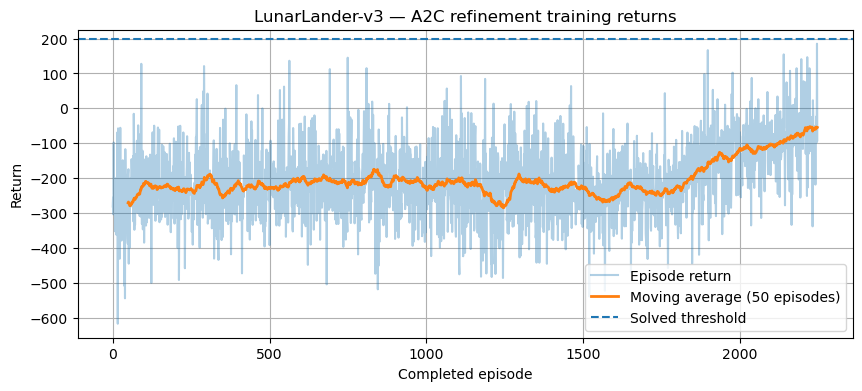

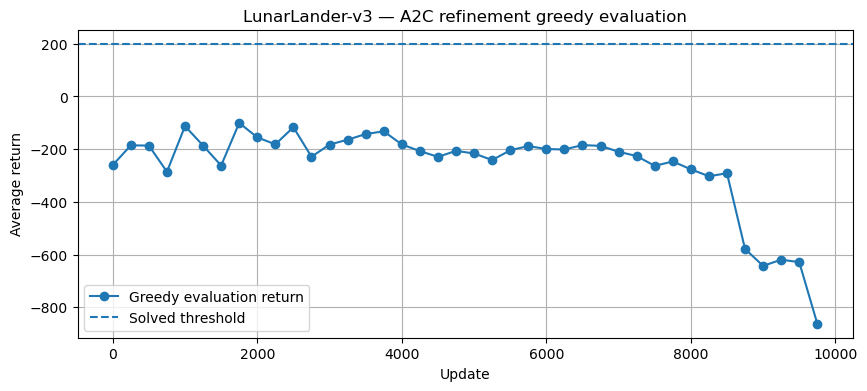

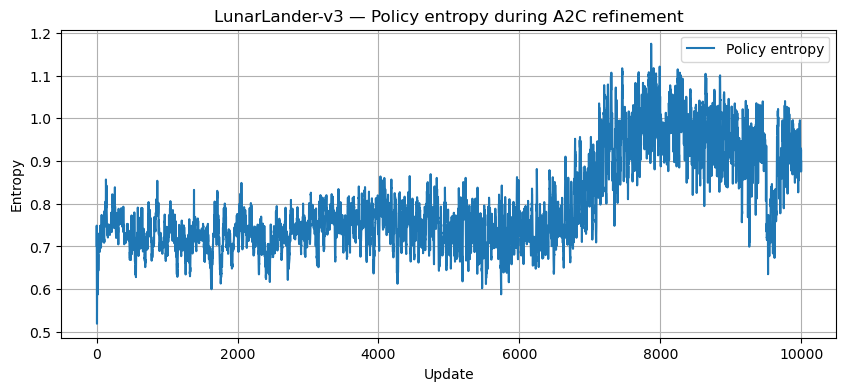

In [11]:
# === PLOTS — Best A2C LunarLander refinement ===

import numpy as np
import matplotlib.pyplot as plt

def moving_average(x, window=50):
    x = np.array(x, dtype=float)
    if len(x) < window:
        return None
    return np.convolve(x, np.ones(window) / window, mode="valid")


# Training returns
plt.figure(figsize=(10, 4))
plt.plot(results_ll_refine["completed_returns"], alpha=0.35, label="Episode return")

ma = moving_average(results_ll_refine["completed_returns"], window=50)

if ma is not None:
    plt.plot(
        range(49, 49 + len(ma)),
        ma,
        linewidth=2,
        label="Moving average (50 episodes)"
    )

plt.axhline(200, linestyle="--", label="Solved threshold")
plt.xlabel("Completed episode")
plt.ylabel("Return")
plt.title("LunarLander-v3 — A2C refinement training returns")
plt.legend()
plt.grid(True)
plt.show()


# Greedy evaluation curve
eval_every = 250

eval_x = np.arange(len(results_ll_refine["eval_avg_returns"])) * eval_every

plt.figure(figsize=(10, 4))
plt.plot(
    eval_x,
    results_ll_refine["eval_avg_returns"],
    marker="o",
    label="Greedy evaluation return"
)

plt.axhline(200, linestyle="--", label="Solved threshold")
plt.xlabel("Update")
plt.ylabel("Average return")
plt.title("LunarLander-v3 — A2C refinement greedy evaluation")
plt.legend()
plt.grid(True)
plt.show()


# Entropy curve
plt.figure(figsize=(10, 4))
plt.plot(results_ll_refine["entropy_values"], label="Policy entropy")
plt.xlabel("Update")
plt.ylabel("Entropy")
plt.title("LunarLander-v3 — Policy entropy during A2C refinement")
plt.legend()
plt.grid(True)
plt.show()

In [17]:
# === LIVE RENDER — Multiple greedy LunarLander episodes ===

import time
import numpy as np
import torch
import gymnasium as gym

selected_checkpoint = "best_a2c_lunarlander_refine_seed2112.pt"

n_render_episodes = 10
seed_start = 9000

env_live = gym.make(
    "LunarLander-v3",
    enable_wind=False,
    render_mode="human"
)

net_live = A2CNetLunarStable(env_live)
net_live.load_state_dict(torch.load(selected_checkpoint))
net_live.eval()

episode_returns = []
episode_lengths = []
all_actions = []

with torch.no_grad():
    for ep in range(n_render_episodes):

        obs, _ = env_live.reset(seed=seed_start + ep)

        ep_return = 0.0
        ep_length = 0
        ep_actions = []

        terminated = False
        truncated = False

        print("\n" + "=" * 60)
        print(f"Rendering episode {ep + 1}/{n_render_episodes}")
        print("=" * 60)

        while not (terminated or truncated):

            obs_t = torch.tensor(obs, dtype=torch.float32) / obs_scale_ll_raw

            probs = net_live.get_action_probs(obs_t, temperature=1e-8)
            action = probs.argmax().item()

            obs, reward, terminated, truncated, _ = env_live.step(action)

            ep_return += reward
            ep_length += 1

            ep_actions.append(action)
            all_actions.append(action)

        episode_returns.append(ep_return)
        episode_lengths.append(ep_length)

        action_counts = np.bincount(ep_actions, minlength=4)
        action_freq = action_counts / action_counts.sum()

        print(f"Episode return: {ep_return:.2f}")
        print(f"Episode length: {ep_length}")
        print("Action frequencies:")
        print(f"  Action 0 - do nothing:   {action_freq[0]:.3f}")
        print(f"  Action 1 - left engine:  {action_freq[1]:.3f}")
        print(f"  Action 2 - main engine:  {action_freq[2]:.3f}")
        print(f"  Action 3 - right engine: {action_freq[3]:.3f}")

        # Small pause between episodes, useful to visually separate them
        time.sleep(1.0)

env_live.close()

episode_returns = np.array(episode_returns)
episode_lengths = np.array(episode_lengths)

print("\n" + "=" * 60)
print("LIVE RENDER SUMMARY")
print("=" * 60)
print(f"Average return:      {episode_returns.mean():.2f}")
print(f"Std return:          {episode_returns.std():.2f}")
print(f"Min return:          {episode_returns.min():.2f}")
print(f"Max return:          {episode_returns.max():.2f}")
print(f"Average length:      {episode_lengths.mean():.2f}")
print(f"Success rate >= 200: {np.mean(episode_returns >= 200) * 100:.1f}%")

overall_action_counts = np.bincount(all_actions, minlength=4)
overall_action_freq = overall_action_counts / overall_action_counts.sum()

print("\nOverall action frequencies:")
print(f"  Action 0 - do nothing:   {overall_action_freq[0]:.3f}")
print(f"  Action 1 - left engine:  {overall_action_freq[1]:.3f}")
print(f"  Action 2 - main engine:  {overall_action_freq[2]:.3f}")
print(f"  Action 3 - right engine: {overall_action_freq[3]:.3f}")


Rendering episode 1/10
Episode return: -114.80
Episode length: 82
Action frequencies:
  Action 0 - do nothing:   0.878
  Action 1 - left engine:  0.000
  Action 2 - main engine:  0.122
  Action 3 - right engine: 0.000

Rendering episode 2/10
Episode return: -158.33
Episode length: 64
Action frequencies:
  Action 0 - do nothing:   0.812
  Action 1 - left engine:  0.000
  Action 2 - main engine:  0.188
  Action 3 - right engine: 0.000

Rendering episode 3/10
Episode return: -95.79
Episode length: 62
Action frequencies:
  Action 0 - do nothing:   0.790
  Action 1 - left engine:  0.000
  Action 2 - main engine:  0.210
  Action 3 - right engine: 0.000

Rendering episode 4/10
Episode return: -90.48
Episode length: 133
Action frequencies:
  Action 0 - do nothing:   0.496
  Action 1 - left engine:  0.000
  Action 2 - main engine:  0.504
  Action 3 - right engine: 0.000

Rendering episode 5/10
Episode return: -103.45
Episode length: 63
Action frequencies:
  Action 0 - do nothing:   0.825
  Act

In [13]:
# === FINAL SELECTED A2C CHECKPOINT ===

selected_checkpoint = "best_a2c_lunarlander_refine_seed2112.pt"

net_ll_best = A2CNetLunarStable(env_ll_eval_refine)
net_ll_best.load_state_dict(torch.load(selected_checkpoint))
net_ll_best.eval()

print("Selected checkpoint:", selected_checkpoint)

print("\n=== FINAL GREEDY EVALUATION ===")
diagnostics_best_greedy = evaluate_lunarlander_detailed(
    env_ll_eval_refine,
    net_ll_best,
    obs_scale_ll_raw,
    n_eval=100
)

print("\n=== FINAL STOCHASTIC EVALUATION ===")
diagnostics_best_stochastic = evaluate_lunarlander_stochastic(
    env_ll_eval_refine,
    net_ll_best,
    obs_scale_ll_raw,
    n_eval=100
)

Selected checkpoint: best_a2c_lunarlander_refine_seed2112.pt

=== FINAL GREEDY EVALUATION ===
LUNARLANDER DETAILED GREEDY EVALUATION
Average return:       -104.75
Std return:           68.36
Min return:           -290.76
Max return:           164.80
Average length:       96.52
Success rate >= 200:  0.0%
Terminated episodes:  100/100
Truncated episodes:   0/100

Action frequencies:
  Action 0 - do nothing:   0.696
  Action 1 - left engine:  0.012
  Action 2 - main engine:  0.290
  Action 3 - right engine: 0.001

=== FINAL STOCHASTIC EVALUATION ===
LUNARLANDER STOCHASTIC EVALUATION
Average return:       -145.27
Std return:           86.43
Min return:           -457.12
Max return:           18.29
Average length:       115.65
Success rate >= 200:  0.0%
Terminated episodes:  100/100
Truncated episodes:   0/100

Action frequencies:
  Action 0 - do nothing:   0.623
  Action 1 - left engine:  0.004
  Action 2 - main engine:  0.367
  Action 3 - right engine: 0.005


In [6]:
# === LUNARLANDER — Final A2C attempt with separate actor and critic ===

seed = 2112

torch.manual_seed(seed)
np.random.seed(seed)

n_envs = 16

env_ll_vec_sep = gym.vector.SyncVectorEnv(
    [make_lunarlander_env(seed + 5000 + i) for i in range(n_envs)]
)

env_ll_eval_sep = gym.make("LunarLander-v3", enable_wind=False)
env_ll_eval_sep.reset(seed=seed + 6000)
env_ll_eval_sep.action_space.seed(seed + 6000)

obs_scale_ll_raw = lunarlander_obs_scale_raw()

net_ll_sep = A2CNetLunarSeparate(env_ll_eval_sep)

results_ll_sep = a2c_vectorized_lunarlander_stable(
    net_ll_sep,
    env_ll_vec_sep,
    env_ll_eval_sep,
    obs_scale_ll_raw,

    gamma=0.995,

    lr=8.3e-4,

    value_coef=0.5,

    entropy_coef=0.0005,
    entropy_coef_min=0.00001,

    total_timesteps=1_000_000,
    n_steps=5,

    eval_every=250,
    eval_episodes=50,

    reward_scale=1.0,
    clip_rewards=False,

    solved_threshold=200.0,

    gae_lambda=1.0,

    optimizer="rmsprop",

    checkpoint_path="best_a2c_lunarlander_separate_seed2112.pt",

    normalize_advantage=False,
    grad_clip=0.5,

    verbose=True,
    stop_when_solved=False,
)


Update: 0
  Timesteps:          80
  Completed episodes: 0
  Avg Return (±std):  0.00 ± 0.00
  Avg Length:         0.0
  Actor Loss:         -0.3065
  Critic Loss:        1.8783
  Entropy:            1.3863
  Entropy coef:       0.00050
  LR:                 0.000830
💾 New best EVAL model saved to best_a2c_lunarlander_separate_seed2112.pt! EvalReturn = -170.32
  [EVAL update.0] AvgReturn: -170.3 | AvgLength: 72.8

Update: 50
  Timesteps:          4080
  Completed episodes: 30
  Avg Return (±std):  -178.30 ± 113.44
  Avg Length:         116.9
  Actor Loss:         -2.4627
  Critic Loss:        2.9619
  Entropy:            1.2180
  Entropy coef:       0.00050
  LR:                 0.000827
📈 New best TRAINING model saved to best_a2c_lunarlander_separate_seed2112_best_train.pt! TrainAvgReturn = -204.47

Update: 100
  Timesteps:          8080
  Completed episodes: 52
  Avg Return (±std):  -204.47 ± 109.69
  Avg Length:         131.3
  Actor Loss:         -1.1253
  Critic Loss:        3.16

In [7]:
# === EVALUATE SEPARATE ACTOR-CRITIC A2C ===

selected_checkpoint_sep = "best_a2c_lunarlander_separate_seed2112.pt"

net_ll_sep_best = A2CNetLunarSeparate(env_ll_eval_sep)
net_ll_sep_best.load_state_dict(torch.load(selected_checkpoint_sep))
net_ll_sep_best.eval()

print("Selected checkpoint:", selected_checkpoint_sep)

print("\n=== GREEDY EVALUATION ===")
diagnostics_sep_greedy = evaluate_lunarlander_detailed(
    env_ll_eval_sep,
    net_ll_sep_best,
    obs_scale_ll_raw,
    n_eval=100
)

print("\n=== STOCHASTIC EVALUATION ===")
diagnostics_sep_stochastic = evaluate_lunarlander_stochastic(
    env_ll_eval_sep,
    net_ll_sep_best,
    obs_scale_ll_raw,
    n_eval=100
)

Selected checkpoint: best_a2c_lunarlander_separate_seed2112.pt

=== GREEDY EVALUATION ===
LUNARLANDER DETAILED GREEDY EVALUATION
Average return:       98.61
Std return:           118.64
Min return:           -161.34
Max return:           257.81
Average length:       515.98
Success rate >= 200:  15.0%
Terminated episodes:  98/100
Truncated episodes:   2/100

Action frequencies:
  Action 0 - do nothing:   0.113
  Action 1 - left engine:  0.225
  Action 2 - main engine:  0.469
  Action 3 - right engine: 0.194

=== STOCHASTIC EVALUATION ===
LUNARLANDER STOCHASTIC EVALUATION
Average return:       110.57
Std return:           113.97
Min return:           -188.48
Max return:           272.00
Average length:       524.33
Success rate >= 200:  27.0%
Terminated episodes:  85/100
Truncated episodes:   15/100

Action frequencies:
  Action 0 - do nothing:   0.203
  Action 1 - left engine:  0.234
  Action 2 - main engine:  0.396
  Action 3 - right engine: 0.166


In [8]:
selected_checkpoint = "best_a2c_lunarlander_separate_seed2112.pt"

env_live = gym.make(
    "LunarLander-v3",
    enable_wind=False,
    render_mode="human"
)

net_live = A2CNetLunarSeparate(env_live)
net_live.load_state_dict(torch.load(selected_checkpoint))
net_live.eval()

A2CNetLunarSeparate(
  (actor): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=4, bias=True)
  )
  (critic): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)

In [9]:
# === CHECKPOINT COMPARISON — A2CNetLunarSeparate ===

import os

candidate_checkpoints_sep = [
    "best_a2c_lunarlander_separate_seed2112.pt",
    "best_a2c_lunarlander_separate_seed2112_best_train.pt",
    "best_a2c_lunarlander_separate_seed2112_last.pt",
]

for ckpt in candidate_checkpoints_sep:
    if os.path.exists(ckpt):
        print("\n" + "=" * 80)
        print(f"CHECKPOINT: {ckpt}")
        print("=" * 80)

        net_tmp = A2CNetLunarSeparate(env_ll_eval_sep)
        net_tmp.load_state_dict(torch.load(ckpt))
        net_tmp.eval()

        print("\n--- GREEDY EVALUATION ---")
        diagnostics_greedy = evaluate_lunarlander_detailed(
            env_ll_eval_sep,
            net_tmp,
            obs_scale_ll_raw,
            n_eval=200
        )

        print("\n--- STOCHASTIC EVALUATION ---")
        diagnostics_stochastic = evaluate_lunarlander_stochastic(
            env_ll_eval_sep,
            net_tmp,
            obs_scale_ll_raw,
            n_eval=200
        )
    else:
        print(f"Checkpoint not found: {ckpt}")


CHECKPOINT: best_a2c_lunarlander_separate_seed2112.pt

--- GREEDY EVALUATION ---
LUNARLANDER DETAILED GREEDY EVALUATION
Average return:       109.43
Std return:           111.84
Min return:           -120.29
Max return:           289.79
Average length:       512.89
Success rate >= 200:  20.5%
Terminated episodes:  195/200
Truncated episodes:   5/200

Action frequencies:
  Action 0 - do nothing:   0.111
  Action 1 - left engine:  0.240
  Action 2 - main engine:  0.465
  Action 3 - right engine: 0.184

--- STOCHASTIC EVALUATION ---
LUNARLANDER STOCHASTIC EVALUATION
Average return:       100.69
Std return:           122.68
Min return:           -221.34
Max return:           304.19
Average length:       503.98
Success rate >= 200:  28.5%
Terminated episodes:  181/200
Truncated episodes:   19/200

Action frequencies:
  Action 0 - do nothing:   0.198
  Action 1 - left engine:  0.202
  Action 2 - main engine:  0.419
  Action 3 - right engine: 0.181

CHECKPOINT: best_a2c_lunarlander_separate_

In [10]:
# === LIVE RENDER — Multiple greedy episodes with A2CNetLunarSeparate ===

selected_checkpoint = "best_a2c_lunarlander_separate_seed2112.pt"

n_render_episodes = 10
seed_start = 12000

env_live = gym.make(
    "LunarLander-v3",
    enable_wind=False,
    render_mode="human"
)

net_live = A2CNetLunarSeparate(env_live)
net_live.load_state_dict(torch.load(selected_checkpoint))
net_live.eval()

episode_returns = []
episode_lengths = []
all_actions = []

with torch.no_grad():
    for ep in range(n_render_episodes):

        obs, _ = env_live.reset(seed=seed_start + ep)

        ep_return = 0.0
        ep_length = 0
        ep_actions = []

        terminated = False
        truncated = False

        print("\n" + "=" * 60)
        print(f"Rendering episode {ep + 1}/{n_render_episodes}")
        print("=" * 60)

        while not (terminated or truncated):

            obs_t = torch.tensor(obs, dtype=torch.float32) / obs_scale_ll_raw

            probs = net_live.get_action_probs(obs_t, temperature=1e-8)
            action = probs.argmax().item()

            obs, reward, terminated, truncated, _ = env_live.step(action)

            ep_return += reward
            ep_length += 1

            ep_actions.append(action)
            all_actions.append(action)

        episode_returns.append(ep_return)
        episode_lengths.append(ep_length)

        action_counts = np.bincount(ep_actions, minlength=4)
        action_freq = action_counts / action_counts.sum()

        print(f"Episode return: {ep_return:.2f}")
        print(f"Episode length: {ep_length}")
        print("Action frequencies:")
        print(f"  Action 0 - do nothing:   {action_freq[0]:.3f}")
        print(f"  Action 1 - left engine:  {action_freq[1]:.3f}")
        print(f"  Action 2 - main engine:  {action_freq[2]:.3f}")
        print(f"  Action 3 - right engine: {action_freq[3]:.3f}")

env_live.close()

episode_returns = np.array(episode_returns)
episode_lengths = np.array(episode_lengths)

print("\n" + "=" * 60)
print("LIVE RENDER SUMMARY")
print("=" * 60)
print(f"Average return:      {episode_returns.mean():.2f}")
print(f"Std return:          {episode_returns.std():.2f}")
print(f"Min return:          {episode_returns.min():.2f}")
print(f"Max return:          {episode_returns.max():.2f}")
print(f"Average length:      {episode_lengths.mean():.2f}")
print(f"Success rate >= 200: {np.mean(episode_returns >= 200) * 100:.1f}%")

overall_action_counts = np.bincount(all_actions, minlength=4)
overall_action_freq = overall_action_counts / overall_action_counts.sum()

print("\nOverall action frequencies:")
print(f"  Action 0 - do nothing:   {overall_action_freq[0]:.3f}")
print(f"  Action 1 - left engine:  {overall_action_freq[1]:.3f}")
print(f"  Action 2 - main engine:  {overall_action_freq[2]:.3f}")
print(f"  Action 3 - right engine: {overall_action_freq[3]:.3f}")


Rendering episode 1/10
Episode return: 50.66
Episode length: 1000
Action frequencies:
  Action 0 - do nothing:   0.136
  Action 1 - left engine:  0.575
  Action 2 - main engine:  0.208
  Action 3 - right engine: 0.081

Rendering episode 2/10
Episode return: 192.25
Episode length: 490
Action frequencies:
  Action 0 - do nothing:   0.120
  Action 1 - left engine:  0.190
  Action 2 - main engine:  0.496
  Action 3 - right engine: 0.194

Rendering episode 3/10
Episode return: 159.04
Episode length: 507
Action frequencies:
  Action 0 - do nothing:   0.124
  Action 1 - left engine:  0.189
  Action 2 - main engine:  0.491
  Action 3 - right engine: 0.195

Rendering episode 4/10
Episode return: 177.63
Episode length: 472
Action frequencies:
  Action 0 - do nothing:   0.123
  Action 1 - left engine:  0.189
  Action 2 - main engine:  0.496
  Action 3 - right engine: 0.193

Rendering episode 5/10
Episode return: 154.95
Episode length: 573
Action frequencies:
  Action 0 - do nothing:   0.031
  Ac

In [11]:
# === LUNARLANDER — Landing refinement from best separate A2C checkpoint ===

seed = 2112

torch.manual_seed(seed)
np.random.seed(seed)

n_envs = 16

env_ll_vec_landing_refine = gym.vector.SyncVectorEnv(
    [make_lunarlander_env(seed + 7000 + i) for i in range(n_envs)]
)

env_ll_eval_landing_refine = gym.make("LunarLander-v3", enable_wind=False)
env_ll_eval_landing_refine.reset(seed=seed + 8000)
env_ll_eval_landing_refine.action_space.seed(seed + 8000)

obs_scale_ll_raw = lunarlander_obs_scale_raw()

net_ll_landing_refine = A2CNetLunarSeparate(env_ll_eval_landing_refine)

net_ll_landing_refine.load_state_dict(
    torch.load("best_a2c_lunarlander_separate_seed2112.pt")
)

results_ll_landing_refine = a2c_vectorized_lunarlander_stable(
    net_ll_landing_refine,
    env_ll_vec_landing_refine,
    env_ll_eval_landing_refine,
    obs_scale_ll_raw,

    gamma=0.995,

    # Much lower LR: refine the existing landing behaviour without destroying it
    lr=1.0e-4,

    value_coef=0.5,

    # Keep a small amount of exploration, but less than before
    entropy_coef=0.00008,
    entropy_coef_min=0.00001,

    # Short refinement: the model already learned useful behaviour
    total_timesteps=300_000,
    n_steps=5,

    # More robust evaluation
    eval_every=250,
    eval_episodes=100,

    reward_scale=1.0,
    clip_rewards=False,

    solved_threshold=200.0,

    gae_lambda=1.0,

    optimizer="rmsprop",

    checkpoint_path="best_a2c_lunarlander_landing_refine_seed2112.pt",

    normalize_advantage=False,
    grad_clip=0.5,

    verbose=True,
    stop_when_solved=False,
)


Update: 0
  Timesteps:          80
  Completed episodes: 0
  Avg Return (±std):  0.00 ± 0.00
  Avg Length:         0.0
  Actor Loss:         0.6214
  Critic Loss:        3.6454
  Entropy:            0.4223
  Entropy coef:       0.00008
  LR:                 0.000100
💾 New best EVAL model saved to best_a2c_lunarlander_landing_refine_seed2112.pt! EvalReturn = 104.18
  [EVAL update.0] AvgReturn: 104.2 | AvgLength: 526.7

Update: 50
  Timesteps:          4080
  Completed episodes: 0
  Avg Return (±std):  0.00 ± 0.00
  Avg Length:         0.0
  Actor Loss:         -0.0554
  Critic Loss:        0.4358
  Entropy:            0.9609
  Entropy coef:       0.00008
  LR:                 0.000099

Update: 100
  Timesteps:          8080
  Completed episodes: 14
  Avg Return (±std):  57.80 ± 133.31
  Avg Length:         393.0
  Actor Loss:         0.4240
  Critic Loss:        1.1195
  Entropy:            0.7747
  Entropy coef:       0.00008
  LR:                 0.000097

Update: 150
  Timesteps:   

In [12]:
# === FINAL CHECKPOINT COMPARISON — Separate A2C vs landing refinement ===

candidate_checkpoints_final = [
    "best_a2c_lunarlander_separate_seed2112.pt",
    "best_a2c_lunarlander_landing_refine_seed2112.pt",
    "best_a2c_lunarlander_landing_refine_seed2112_best_train.pt",
    "best_a2c_lunarlander_landing_refine_seed2112_last.pt",
]

for ckpt in candidate_checkpoints_final:
    if os.path.exists(ckpt):
        print("\n" + "=" * 80)
        print(f"CHECKPOINT: {ckpt}")
        print("=" * 80)

        net_tmp = A2CNetLunarSeparate(env_ll_eval_landing_refine)
        net_tmp.load_state_dict(torch.load(ckpt))
        net_tmp.eval()

        print("\n--- GREEDY EVALUATION ---")
        diagnostics_greedy = evaluate_lunarlander_detailed(
            env_ll_eval_landing_refine,
            net_tmp,
            obs_scale_ll_raw,
            n_eval=200
        )

        print("\n--- STOCHASTIC EVALUATION ---")
        diagnostics_stochastic = evaluate_lunarlander_stochastic(
            env_ll_eval_landing_refine,
            net_tmp,
            obs_scale_ll_raw,
            n_eval=200
        )
    else:
        print(f"Checkpoint not found: {ckpt}")


CHECKPOINT: best_a2c_lunarlander_separate_seed2112.pt

--- GREEDY EVALUATION ---
LUNARLANDER DETAILED GREEDY EVALUATION
Average return:       99.97
Std return:           115.59
Min return:           -190.01
Max return:           292.66
Average length:       521.86
Success rate >= 200:  13.5%
Terminated episodes:  196/200
Truncated episodes:   4/200

Action frequencies:
  Action 0 - do nothing:   0.113
  Action 1 - left engine:  0.231
  Action 2 - main engine:  0.460
  Action 3 - right engine: 0.196

--- STOCHASTIC EVALUATION ---
LUNARLANDER STOCHASTIC EVALUATION
Average return:       100.57
Std return:           119.75
Min return:           -133.97
Max return:           295.25
Average length:       508.26
Success rate >= 200:  24.0%
Terminated episodes:  180/200
Truncated episodes:   20/200

Action frequencies:
  Action 0 - do nothing:   0.190
  Action 1 - left engine:  0.233
  Action 2 - main engine:  0.413
  Action 3 - right engine: 0.164

CHECKPOINT: best_a2c_lunarlander_landing_re

In [13]:
# === TEMPERATURE SWEEP — A2C stochastic policy control ===

from torch.distributions import Categorical
import numpy as np
import torch

def evaluate_lunarlander_temperature(
    env,
    net,
    obs_scale,
    temperature=1.0,
    n_eval=200,
    seed_start=30000,
    maxlen=1000
):
    net.eval()

    returns = []
    lengths = []
    all_actions = []

    n_terminated = 0
    n_truncated = 0

    with torch.no_grad():
        for ep in range(n_eval):
            obs, _ = env.reset(seed=seed_start + ep)

            ep_return = 0.0
            ep_length = 0

            terminated = False
            truncated = False

            for _ in range(maxlen):
                obs_t = torch.tensor(obs, dtype=torch.float32) / obs_scale

                logits, _ = net.get_logits_and_value(obs_t)

                # temperature < 1: more deterministic
                # temperature > 1: more exploratory
                dist = Categorical(logits=logits / temperature)
                action = dist.sample().item()

                obs, reward, terminated, truncated, _ = env.step(action)

                ep_return += reward
                ep_length += 1
                all_actions.append(action)

                if terminated or truncated:
                    break

            returns.append(ep_return)
            lengths.append(ep_length)

            if terminated:
                n_terminated += 1
            if truncated:
                n_truncated += 1

    returns_np = np.array(returns)

    action_counts = np.bincount(all_actions, minlength=4)
    action_freq = action_counts / action_counts.sum()

    return {
        "temperature": temperature,
        "avg_return": returns_np.mean(),
        "std_return": returns_np.std(),
        "min_return": returns_np.min(),
        "max_return": returns_np.max(),
        "avg_length": np.mean(lengths),
        "success_rate": np.mean(returns_np >= 200) * 100,
        "terminated": n_terminated,
        "truncated": n_truncated,
        "action_freq": action_freq,
    }


# Load current best model
env_temp_eval = gym.make("LunarLander-v3", enable_wind=False)
env_temp_eval.reset(seed=2112 + 9000)
env_temp_eval.action_space.seed(2112 + 9000)

net_temp = A2CNetLunarSeparate(env_temp_eval)
net_temp.load_state_dict(
    torch.load("best_a2c_lunarlander_landing_refine_seed2112_best_train.pt")
)
net_temp.eval()

temperatures = [0.25, 0.5, 0.75, 1.0, 1.25]

temperature_results = []

for temp in temperatures:
    result = evaluate_lunarlander_temperature(
        env_temp_eval,
        net_temp,
        obs_scale_ll_raw,
        temperature=temp,
        n_eval=200,
        seed_start=30000
    )

    temperature_results.append(result)

    print("\n" + "=" * 70)
    print(f"TEMPERATURE: {temp}")
    print("=" * 70)
    print(f"Average return:       {result['avg_return']:.2f}")
    print(f"Std return:           {result['std_return']:.2f}")
    print(f"Min return:           {result['min_return']:.2f}")
    print(f"Max return:           {result['max_return']:.2f}")
    print(f"Average length:       {result['avg_length']:.2f}")
    print(f"Success rate >= 200:  {result['success_rate']:.1f}%")
    print(f"Terminated episodes:  {result['terminated']}/200")
    print(f"Truncated episodes:   {result['truncated']}/200")
    print("Action frequencies:")
    print(f"  Action 0 - do nothing:   {result['action_freq'][0]:.3f}")
    print(f"  Action 1 - left engine:  {result['action_freq'][1]:.3f}")
    print(f"  Action 2 - main engine:  {result['action_freq'][2]:.3f}")
    print(f"  Action 3 - right engine: {result['action_freq'][3]:.3f}")


TEMPERATURE: 0.25
Average return:       111.45
Std return:           106.66
Min return:           -159.03
Max return:           250.02
Average length:       709.92
Success rate >= 200:  15.5%
Terminated episodes:  190/200
Truncated episodes:   10/200
Action frequencies:
  Action 0 - do nothing:   0.091
  Action 1 - left engine:  0.205
  Action 2 - main engine:  0.505
  Action 3 - right engine: 0.199

TEMPERATURE: 0.5
Average return:       124.24
Std return:           99.97
Min return:           -106.59
Max return:           251.63
Average length:       700.75
Success rate >= 200:  21.5%
Terminated episodes:  182/200
Truncated episodes:   18/200
Action frequencies:
  Action 0 - do nothing:   0.117
  Action 1 - left engine:  0.204
  Action 2 - main engine:  0.485
  Action 3 - right engine: 0.194

TEMPERATURE: 0.75
Average return:       129.27
Std return:           102.50
Min return:           -99.34
Max return:           264.79
Average length:       679.88
Success rate >= 200:  27.5%
Te

In [14]:
# === FINAL SELECTED A2C POLICY ===

final_a2c_checkpoint = "best_a2c_lunarlander_landing_refine_seed2112_best_train.pt"
final_temperature = 1.0

print("Final A2C checkpoint:", final_a2c_checkpoint)
print("Final action selection: stochastic policy")
print("Final temperature:", final_temperature)

Final A2C checkpoint: best_a2c_lunarlander_landing_refine_seed2112_best_train.pt
Final action selection: stochastic policy
Final temperature: 1.0


In [15]:
# === LIVE RENDER — Final A2C stochastic policy with temperature ===

import time
import numpy as np
import torch
import gymnasium as gym
from torch.distributions import Categorical

selected_checkpoint = "best_a2c_lunarlander_landing_refine_seed2112_best_train.pt"
selected_temperature = 1.0

n_render_episodes = 10
seed_start = 40000

env_live = gym.make(
    "LunarLander-v3",
    enable_wind=False,
    render_mode="human"
)

net_live = A2CNetLunarSeparate(env_live)
net_live.load_state_dict(torch.load(selected_checkpoint))
net_live.eval()

episode_returns = []
episode_lengths = []
all_actions = []

with torch.no_grad():
    for ep in range(n_render_episodes):

        obs, _ = env_live.reset(seed=seed_start + ep)

        ep_return = 0.0
        ep_length = 0
        ep_actions = []

        terminated = False
        truncated = False

        print("\n" + "=" * 60)
        print(f"Rendering episode {ep + 1}/{n_render_episodes}")
        print("=" * 60)

        while not (terminated or truncated):

            obs_t = torch.tensor(obs, dtype=torch.float32) / obs_scale_ll_raw

            logits, _ = net_live.get_logits_and_value(obs_t)
            dist = Categorical(logits=logits / selected_temperature)
            action = dist.sample().item()

            obs, reward, terminated, truncated, _ = env_live.step(action)

            ep_return += reward
            ep_length += 1

            ep_actions.append(action)
            all_actions.append(action)

        episode_returns.append(ep_return)
        episode_lengths.append(ep_length)

        action_counts = np.bincount(ep_actions, minlength=4)
        action_freq = action_counts / action_counts.sum()

        print(f"Episode return: {ep_return:.2f}")
        print(f"Episode length: {ep_length}")
        print("Action frequencies:")
        print(f"  Action 0 - do nothing:   {action_freq[0]:.3f}")
        print(f"  Action 1 - left engine:  {action_freq[1]:.3f}")
        print(f"  Action 2 - main engine:  {action_freq[2]:.3f}")
        print(f"  Action 3 - right engine: {action_freq[3]:.3f}")

        time.sleep(1.0)

env_live.close()

episode_returns = np.array(episode_returns)
episode_lengths = np.array(episode_lengths)

print("\n" + "=" * 60)
print("FINAL LIVE RENDER SUMMARY")
print("=" * 60)
print(f"Checkpoint:          {selected_checkpoint}")
print(f"Temperature:         {selected_temperature}")
print(f"Average return:      {episode_returns.mean():.2f}")
print(f"Std return:          {episode_returns.std():.2f}")
print(f"Min return:          {episode_returns.min():.2f}")
print(f"Max return:          {episode_returns.max():.2f}")
print(f"Average length:      {episode_lengths.mean():.2f}")
print(f"Success rate >= 200: {np.mean(episode_returns >= 200) * 100:.1f}%")

overall_action_counts = np.bincount(all_actions, minlength=4)
overall_action_freq = overall_action_counts / overall_action_counts.sum()

print("\nOverall action frequencies:")
print(f"  Action 0 - do nothing:   {overall_action_freq[0]:.3f}")
print(f"  Action 1 - left engine:  {overall_action_freq[1]:.3f}")
print(f"  Action 2 - main engine:  {overall_action_freq[2]:.3f}")
print(f"  Action 3 - right engine: {overall_action_freq[3]:.3f}")


Rendering episode 1/10
Episode return: 202.90
Episode length: 561
Action frequencies:
  Action 0 - do nothing:   0.130
  Action 1 - left engine:  0.159
  Action 2 - main engine:  0.553
  Action 3 - right engine: 0.159

Rendering episode 2/10
Episode return: 178.67
Episode length: 651
Action frequencies:
  Action 0 - do nothing:   0.169
  Action 1 - left engine:  0.171
  Action 2 - main engine:  0.487
  Action 3 - right engine: 0.174

Rendering episode 3/10
Episode return: -49.94
Episode length: 524
Action frequencies:
  Action 0 - do nothing:   0.038
  Action 1 - left engine:  0.172
  Action 2 - main engine:  0.597
  Action 3 - right engine: 0.193

Rendering episode 4/10
Episode return: -61.53
Episode length: 520
Action frequencies:
  Action 0 - do nothing:   0.052
  Action 1 - left engine:  0.179
  Action 2 - main engine:  0.565
  Action 3 - right engine: 0.204

Rendering episode 5/10
Episode return: 62.56
Episode length: 1000
Action frequencies:
  Action 0 - do nothing:   0.353
  Ac